# Demo Real-ESRGAN - Super Resolution

Ce notebook démontre l'utilisation de Real-ESRGAN pour améliorer la résolution d'images.

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

print("✓ Imports OK")

✓ Imports OK


## 1. Configuration

In [15]:
# Chemins
MODEL_PATH = "../src/models/Real-ESRGAN/RealESRGAN_x4plus.pth"
IMAGE_PATH = "../data/raw/DIV2K/DIV2K_train_HR/0800.png"

# Paramètres
SCALE = 4
DEVICE = 'cuda'  # Changez en 'cpu' si pas de GPU

## 2. Charger l'image originale

Taille originale: (1332, 2040, 3)


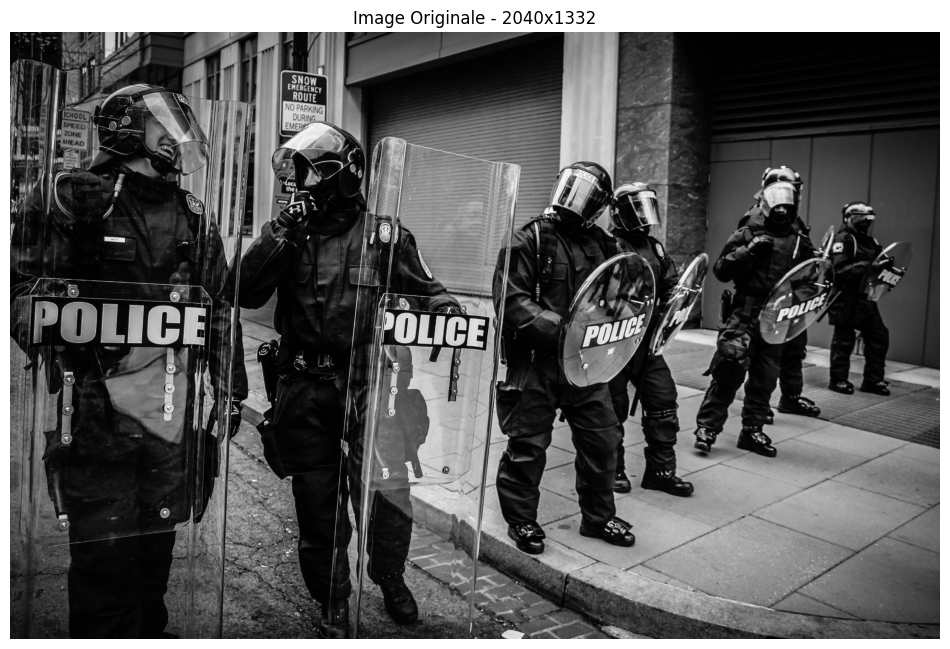

In [16]:
# Charger l'image
img_original = cv2.imread(IMAGE_PATH, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

print(f"Taille originale: {img_rgb.shape}")

# Afficher
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.title(f"Image Originale - {img_rgb.shape[1]}x{img_rgb.shape[0]}")
plt.axis('off')
plt.show()

## 3. Créer une version basse résolution (pour simuler une vraie utilisation)

On va réduire l'image par 4, puis la remonter avec Real-ESRGAN pour voir l'amélioration

Taille basse résolution: (333, 510, 3)


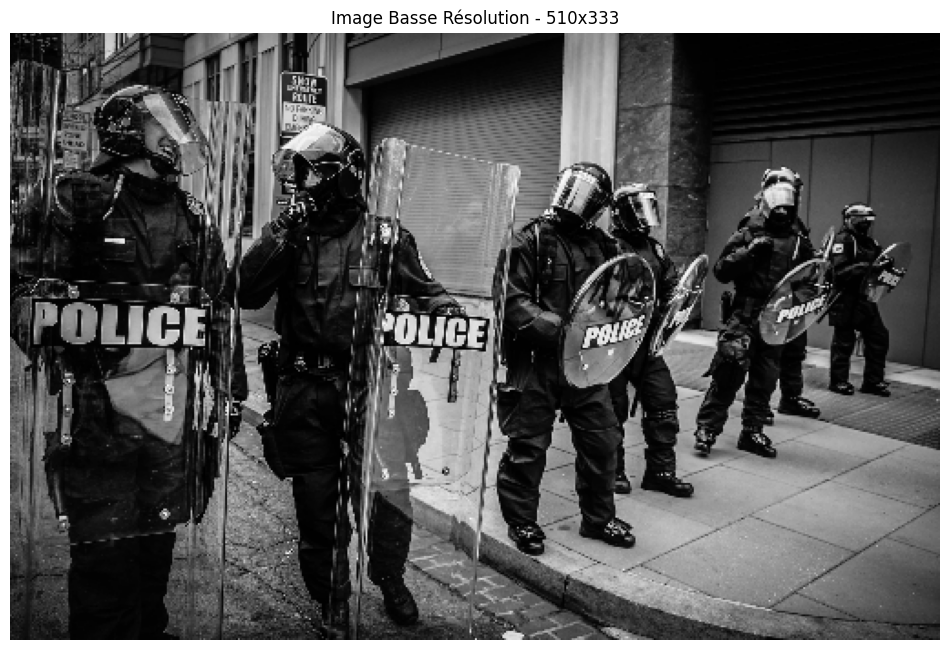

In [17]:
# Créer une version LR (Low Resolution)
h, w = img_original.shape[:2]
img_lr = cv2.resize(img_original, (w // SCALE, h // SCALE), interpolation=cv2.INTER_CUBIC)
img_lr_rgb = cv2.cvtColor(img_lr, cv2.COLOR_BGR2RGB)

print(f"Taille basse résolution: {img_lr_rgb.shape}")

# Afficher
plt.figure(figsize=(12, 8))
plt.imshow(img_lr_rgb)
plt.title(f"Image Basse Résolution - {img_lr_rgb.shape[1]}x{img_lr_rgb.shape[0]}")
plt.axis('off')
plt.show()

## 4. Charger le modèle Real-ESRGAN

In [18]:
# Créer l'architecture RRDBNet
model = RRDBNet(
    num_in_ch=3,      # RGB input
    num_out_ch=3,     # RGB output
    num_feat=64,      # Nombre de features
    num_block=23,     # 23 blocs pour le modèle x4plus
    num_grow_ch=32,   # Growth channels
    scale=SCALE       # Facteur d'upscaling
)

# Wrapper avec RealESRGANer
upsampler = RealESRGANer(
    scale=SCALE,
    model_path=MODEL_PATH,
    model=model,
    tile=0,           # 0 = pas de tiling (traite l'image entière)
    tile_pad=10,
    pre_pad=0,
    half=False,       # FP32 (plus précis que FP16)
    device=DEVICE
)

print("✓ Modèle chargé avec succès!")

✓ Modèle chargé avec succès!


## 5. Appliquer Real-ESRGAN sur l'image basse résolution

In [19]:
# Upscaler l'image LR
print("Upscaling en cours...")
output, _ = upsampler.enhance(img_lr, outscale=SCALE)

# Convertir en RGB pour affichage
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

print(f"✓ Upscaling terminé!")
print(f"Taille après Real-ESRGAN: {output_rgb.shape}")

Upscaling en cours...
✓ Upscaling terminé!
Taille après Real-ESRGAN: (1332, 2040, 3)


## 6. Comparaison Visuelle : AVANT vs APRÈS

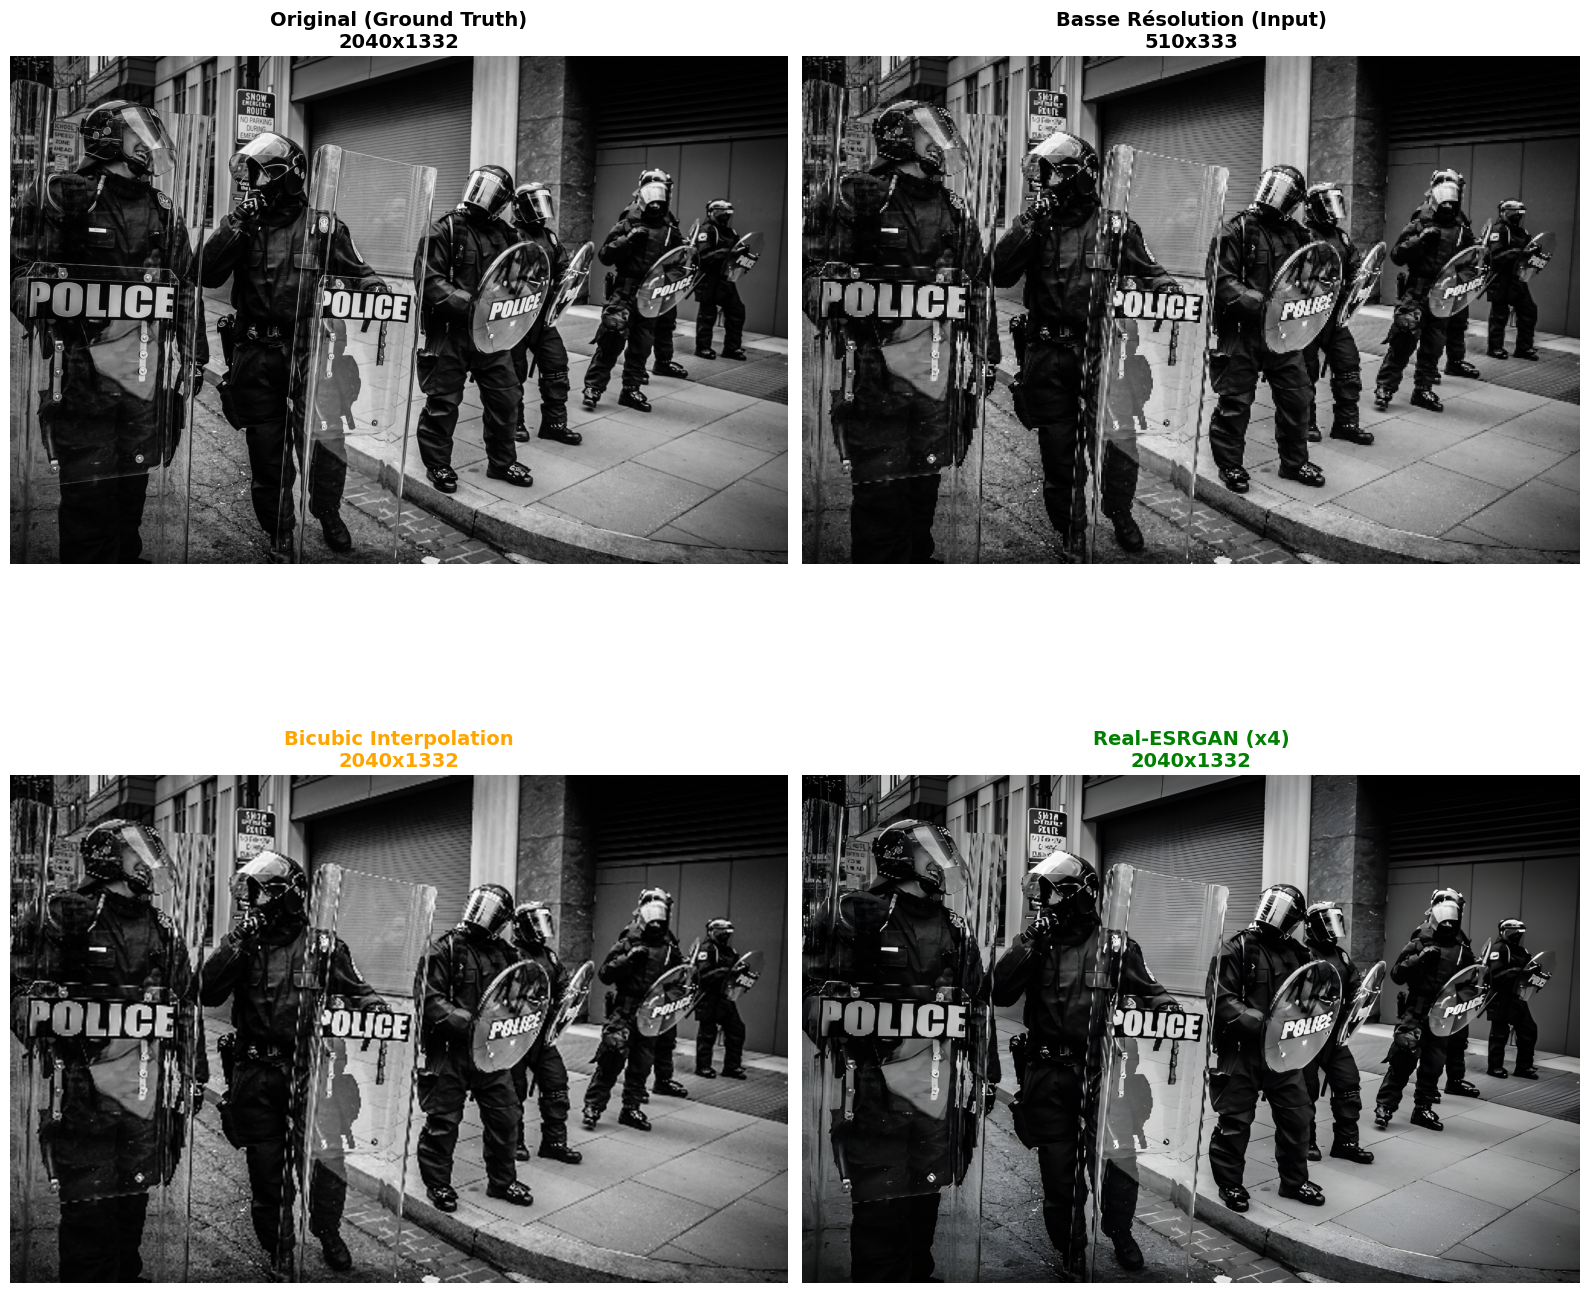

In [20]:
# Upscaler la LR avec bicubic (méthode classique) pour comparaison
img_bicubic = cv2.resize(img_lr, (w, h), interpolation=cv2.INTER_CUBIC)
img_bicubic_rgb = cv2.cvtColor(img_bicubic, cv2.COLOR_BGR2RGB)

# Affichage côte à côte
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Image originale (ground truth)
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title(f"Original (Ground Truth)\n{img_rgb.shape[1]}x{img_rgb.shape[0]}", fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# Image basse résolution
axes[0, 1].imshow(img_lr_rgb)
axes[0, 1].set_title(f"Basse Résolution (Input)\n{img_lr_rgb.shape[1]}x{img_lr_rgb.shape[0]}", fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

# Bicubic interpolation (baseline)
axes[1, 0].imshow(img_bicubic_rgb)
axes[1, 0].set_title(f"Bicubic Interpolation\n{img_bicubic_rgb.shape[1]}x{img_bicubic_rgb.shape[0]}", fontsize=14, fontweight='bold', color='orange')
axes[1, 0].axis('off')

# Real-ESRGAN (notre résultat)
axes[1, 1].imshow(output_rgb)
axes[1, 1].set_title(f"Real-ESRGAN (x{SCALE})\n{output_rgb.shape[1]}x{output_rgb.shape[0]}", fontsize=14, fontweight='bold', color='green')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 7. Zoom sur une région pour voir les détails

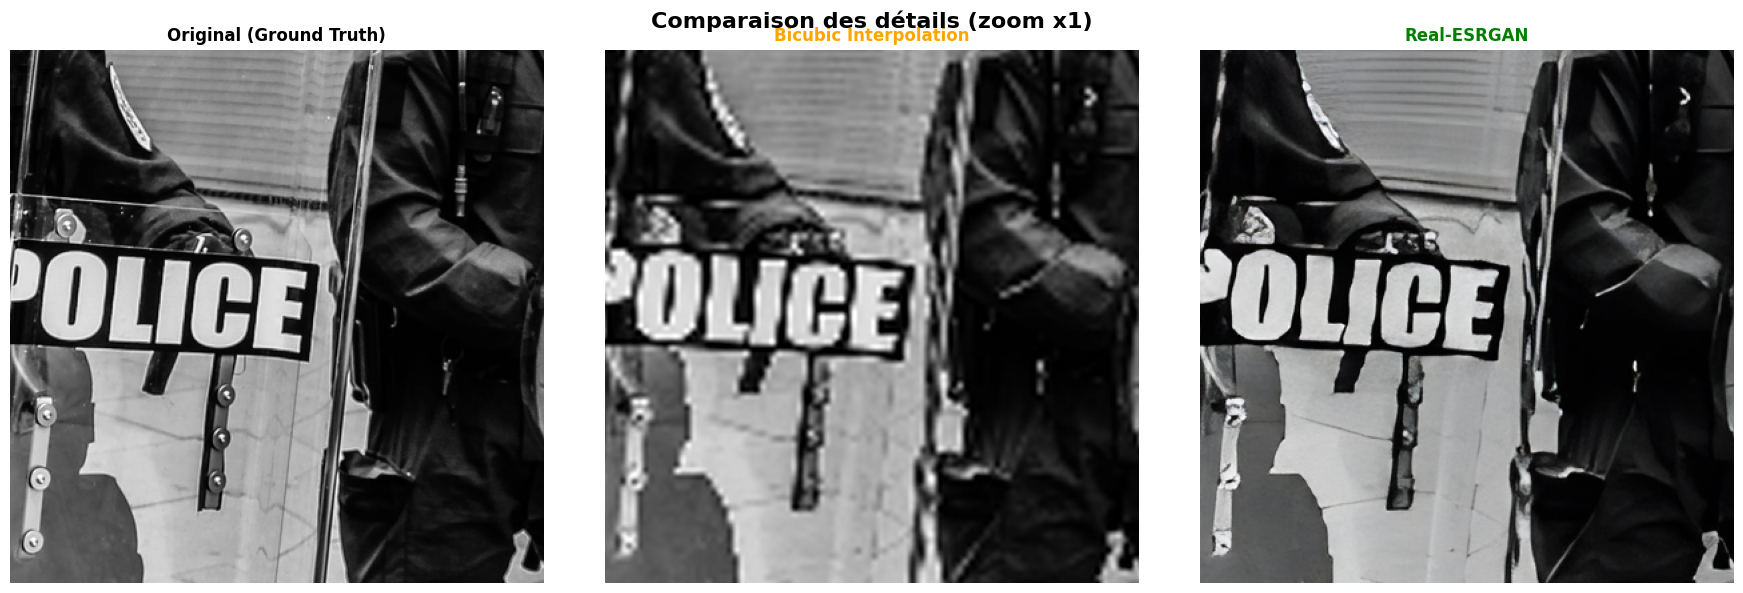

In [21]:
# Prendre un crop au centre
crop_size = 200
center_y, center_x = h // 2, w // 2

y1, y2 = center_y - crop_size, center_y + crop_size
x1, x2 = center_x - crop_size, center_x + crop_size

# Crops
crop_original = img_rgb[y1:y2, x1:x2]
crop_bicubic = img_bicubic_rgb[y1:y2, x1:x2]
crop_esrgan = output_rgb[y1:y2, x1:x2]

# Affichage
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(crop_original)
axes[0].set_title("Original (Ground Truth)", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(crop_bicubic)
axes[1].set_title("Bicubic Interpolation", fontsize=12, fontweight='bold', color='orange')
axes[1].axis('off')

axes[2].imshow(crop_esrgan)
axes[2].set_title("Real-ESRGAN", fontsize=12, fontweight='bold', color='green')
axes[2].axis('off')

plt.suptitle("Comparaison des détails (zoom x1)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Calculer les métriques PSNR et SSIM

In [22]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Calculer PSNR et SSIM pour bicubic
psnr_bicubic = psnr(img_rgb, img_bicubic_rgb)
ssim_bicubic = ssim(img_rgb, img_bicubic_rgb, channel_axis=2)

# Calculer PSNR et SSIM pour Real-ESRGAN
psnr_esrgan = psnr(img_rgb, output_rgb)
ssim_esrgan = ssim(img_rgb, output_rgb, channel_axis=2)

# Afficher les résultats
print("=" * 50)
print("MÉTRIQUES DE QUALITÉ")
print("=" * 50)
print(f"\nBicubic Interpolation:")
print(f"  PSNR: {psnr_bicubic:.2f} dB")
print(f"  SSIM: {ssim_bicubic:.4f}")
print(f"\nReal-ESRGAN:")
print(f"  PSNR: {psnr_esrgan:.2f} dB")
print(f"  SSIM: {ssim_esrgan:.4f}")
print(f"\nAmélioration:")
print(f"  +{psnr_esrgan - psnr_bicubic:.2f} dB en PSNR")
print(f"  +{ssim_esrgan - ssim_bicubic:.4f} en SSIM")
print("=" * 50)

MÉTRIQUES DE QUALITÉ

Bicubic Interpolation:
  PSNR: 24.04 dB
  SSIM: 0.8017

Real-ESRGAN:
  PSNR: 22.93 dB
  SSIM: 0.7382

Amélioration:
  +-1.11 dB en PSNR
  +-0.0635 en SSIM


## 9. Sauvegarder le résultat

In [23]:
# Créer un dossier de sortie
output_dir = Path("../outputs/realesrgan")
output_dir.mkdir(parents=True, exist_ok=True)

# Sauvegarder
output_path = output_dir / "result_x4.png"
cv2.imwrite(str(output_path), output)

print(f"✓ Image sauvegardée: {output_path}")

✓ Image sauvegardée: ../outputs/realesrgan/result_x4.png
